In [1]:
import sys
sys.path.append('../')


import numpy as np
import pickle

from conformal_clustering.utils import sample_gamm, GammaMixture

from sklearn.metrics import adjusted_rand_score

import matplotlib.pyplot as plt

### 30D Example with 5 Isotropic Components
(GaMM30D5v1)

In [2]:
K = 5
d = 30

# generate means in 2D by equispaced points on a circle
means_2d = 8 * np.vstack([np.cos(np.pi * np.linspace(0.05, 0.45, K)),
                      np.sin(np.pi * np.linspace(0.03, 0.47, K))]).T

# embedding the 2D means into higher dimensions by padding with ones
means = np.ones((K, d))
means[:, :2] = means_2d

base_covariances = np.array([np.eye(d) for _ in range(K)])
base_shapes = np.zeros((K, d))
base_scales = np.zeros((K, d))

for k in range(K):
    base_scales[k] = base_covariances[k].diagonal() / means[k]
    base_shapes[k] = means[k] / base_scales[k]

weights = np.ones(K) / K


# check ARI
var_range = np.linspace(0.1, 1, 10)

for var in var_range:
    shapes = base_shapes / var
    scales = base_scales * var
    X, y = sample_gamm(shapes, scales, weights, K*800)
    gamm = GammaMixture(n_components=K, n_init=25, random_state=0)
    gamm.fit(X)
    y_pred = gamm.predict(X)
    ari = adjusted_rand_score(y, y_pred)
    print(f"Variance: {var:.2f}, ARI: {ari:.4f}")

plt.show()

Variance: 0.10, ARI: 1.0000
Variance: 0.20, ARI: 0.9912
Variance: 0.30, ARI: 0.9481
Variance: 0.40, ARI: 0.9038
Variance: 0.50, ARI: 0.8639
Variance: 0.60, ARI: 0.8211
Variance: 0.70, ARI: 0.7648
Variance: 0.80, ARI: 0.7260
Variance: 0.90, ARI: 0.7182
Variance: 1.00, ARI: 0.6864


### **Fixed Sample Size**

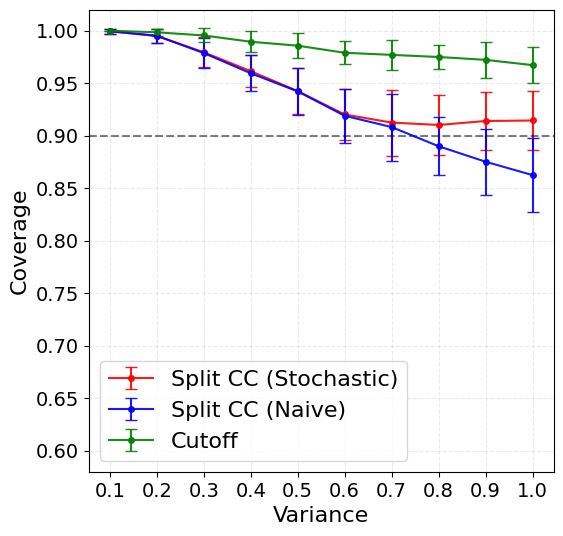

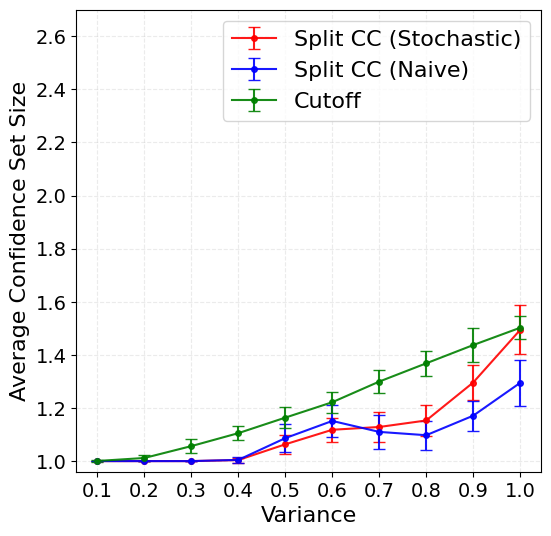

In [3]:
B = 4000
var_range = np.linspace(0.1, 1, 10)


with open(f'Results/GaMM30D5v1.pkl', 'rb') as f:
    results = pickle.load(f)

covs_GaMM, sizes_GaMM = np.zeros((len(var_range), B)), np.zeros((len(var_range), B))
covs_GaMMS, sizes_GaMMS = np.zeros((len(var_range), B)), np.zeros((len(var_range), B))
covs_GaMMC, sizes_GaMMC = np.zeros((len(var_range), B)), np.zeros((len(var_range), B))


for var_idx in range(len(var_range)):
    for b in range(B):
        res = results[var_idx*B + b]
        covs_GaMM[var_idx, b], sizes_GaMM[var_idx, b] = res['GaMM']
        covs_GaMMS[var_idx, b], sizes_GaMMS[var_idx, b] = res['GaMMS']
        covs_GaMMC[var_idx, b], sizes_GaMMC[var_idx, b] = res['GaMM-Cutoff']

# Each row is reshaped to (B//100, 100)
covs_GaMM = np.reshape(covs_GaMM, (len(var_range), -1, 100))
covs_GaMMS = np.reshape(covs_GaMMS, (len(var_range), -1, 100))
covs_GaMMC = np.reshape(covs_GaMMC, (len(var_range), -1, 100))
sizes_GaMM = np.reshape(sizes_GaMM, (len(var_range), -1, 100))
sizes_GaMMS = np.reshape(sizes_GaMMS, (len(var_range), -1, 100))
sizes_GaMMC = np.reshape(sizes_GaMMC, (len(var_range), -1, 100))

# Average over the last axis = reshape to (len(var_range), B//100)
covs_GaMM = np.mean(covs_GaMM, axis=2)
covs_GaMMS = np.mean(covs_GaMMS, axis=2)
covs_GaMMC = np.mean(covs_GaMMC, axis=2)
sizes_GaMM = np.mean(sizes_GaMM, axis=2)
sizes_GaMMS = np.mean(sizes_GaMMS, axis=2)
sizes_GaMMC = np.mean(sizes_GaMMC, axis=2)

# Mean and std over B//100 experiments
covs_GaMM_mean, covs_GaMM_std = np.mean(covs_GaMM, axis=1), np.std(covs_GaMM, axis=1)
covs_GaMMS_mean, covs_GaMMS_std = np.mean(covs_GaMMS, axis=1), np.std(covs_GaMMS, axis=1)
covs_GaMMC_mean, covs_GaMMC_std = np.mean(covs_GaMMC, axis=1), np.std(covs_GaMMC, axis=1)
sizes_GaMM_mean, sizes_GaMM_std = np.mean(sizes_GaMM, axis=1), np.std(sizes_GaMM, axis=1)
sizes_GaMMS_mean, sizes_GaMMS_std = np.mean(sizes_GaMMS, axis=1), np.std(sizes_GaMMS, axis=1)
sizes_GaMMC_mean, sizes_GaMMC_std = np.mean(sizes_GaMMC, axis=1), np.std(sizes_GaMMC, axis=1)


# Errorbars with connected lines
plt.figure(figsize=(6,6))
plt.errorbar(var_range, covs_GaMMS_mean, yerr=covs_GaMMS_std, fmt='ro-', capsize=4, markersize=4, alpha=0.9, label='Split CC (Stochastic)')
plt.errorbar(var_range, covs_GaMM_mean, yerr=covs_GaMM_std, fmt='bo-', capsize=4, markersize=4, alpha=0.9, label='Split CC (Naive)')
plt.errorbar(var_range, covs_GaMMC_mean, yerr=covs_GaMMC_std, fmt='go-', capsize=4, markersize=4, alpha=0.9, label='Cutoff')
plt.axhline(y=0.9, color='k', linestyle='--', alpha=0.5)
plt.xlabel('Variance', fontsize=16)
plt.xticks(ticks=var_range, labels=[f"{v:.1f}" for v in var_range], fontsize=14)
plt.ylabel('Coverage', fontsize=16)
plt.yticks(fontsize=14)
plt.legend(fontsize=16)
plt.grid(True, linestyle="--", alpha=0.25)
plt.ylim((0.58, 1.02))
#plt.savefig('Figures/GaMM30D5v1_coverage.pdf', bbox_inches='tight')
plt.show()


plt.figure(figsize=(6,6))
plt.errorbar(var_range, sizes_GaMMS_mean, yerr=sizes_GaMMS_std, fmt='ro-', capsize=4, markersize=4, alpha=0.9, label='Split CC (Stochastic)')
plt.errorbar(var_range, sizes_GaMM_mean, yerr=sizes_GaMM_std, fmt='bo-', capsize=4, markersize=4, alpha=0.9, label='Split CC (Naive)')
plt.errorbar(var_range, sizes_GaMMC_mean, yerr=sizes_GaMMC_std, fmt='go-', capsize=4, markersize=4, alpha=0.9, label='Cutoff')
plt.xlabel('Variance', fontsize=16)
plt.xticks(ticks=var_range, labels=[f"{v:.1f}" for v in var_range], fontsize=14)
plt.ylabel('Average Confidence Set Size', fontsize=16)
plt.yticks(fontsize=14)
plt.legend(fontsize=16)
plt.grid(True, linestyle="--", alpha=0.25)
plt.ylim((0.96, 2.7))
#plt.savefig('Figures/GaMM30D5v1_size.pdf', bbox_inches='tight')
plt.show()

## **Asymptotic: Increasing Sample Size**

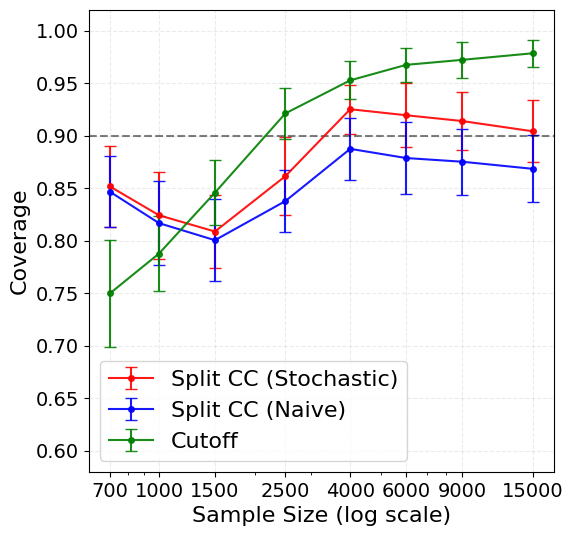

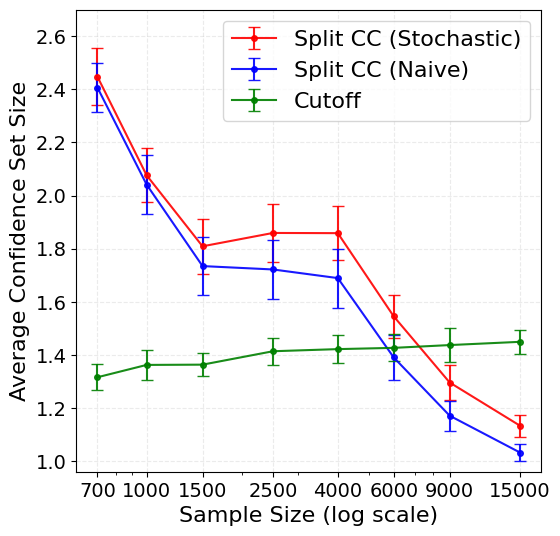

In [4]:
B = 4000
n_range = [700, 1000, 1500, 2500, 4000, 6000, 9000, 15000]

with open(f'Results/GaMM30D5v1_asymp.pkl', 'rb') as f:
    results = pickle.load(f)

asymp_covs_GaMM, asymp_sizes_GaMM = np.zeros((len(n_range), B)), np.zeros((len(n_range), B))
asymp_covs_GaMMS, asymp_sizes_GaMMS = np.zeros((len(n_range), B)), np.zeros((len(n_range), B))
asymp_covs_GaMMC, asymp_sizes_GaMMC = np.zeros((len(n_range), B)), np.zeros((len(n_range), B))


for n_idx in range(len(n_range)):
    for b in range(B):
        res = results[n_idx*B + b]
        asymp_covs_GaMM[n_idx, b], asymp_sizes_GaMM[n_idx, b] = res['GaMM']
        asymp_covs_GaMMS[n_idx, b], asymp_sizes_GaMMS[n_idx, b] = res['GaMMS']
        asymp_covs_GaMMC[n_idx, b], asymp_sizes_GaMMC[n_idx, b] = res['GaMM-Cutoff']

# Each row is reshaped to (B//100, 100)
asymp_covs_GaMM = np.reshape(asymp_covs_GaMM, (len(n_range), -1, 100))
asymp_covs_GaMMS = np.reshape(asymp_covs_GaMMS, (len(n_range), -1, 100))
asymp_covs_GaMMC = np.reshape(asymp_covs_GaMMC, (len(n_range), -1, 100))
asymp_sizes_GaMM = np.reshape(asymp_sizes_GaMM, (len(n_range), -1, 100))
asymp_sizes_GaMMS = np.reshape(asymp_sizes_GaMMS, (len(n_range), -1, 100))
asymp_sizes_GaMMC = np.reshape(asymp_sizes_GaMMC, (len(n_range), -1, 100))

# Average over the last axis = reshape to (len(n_range), B//100)
asymp_covs_GaMM = np.mean(asymp_covs_GaMM, axis=2)
asymp_covs_GaMMS = np.mean(asymp_covs_GaMMS, axis=2)
asymp_covs_GaMMC = np.mean(asymp_covs_GaMMC, axis=2)
asymp_sizes_GaMM = np.mean(asymp_sizes_GaMM, axis=2)
asymp_sizes_GaMMS = np.mean(asymp_sizes_GaMMS, axis=2)
asymp_sizes_GaMMC = np.mean(asymp_sizes_GaMMC, axis=2)

# Mean and std over B//100 experiments
asymp_covs_GaMM_mean, asymp_covs_GaMM_std = np.mean(asymp_covs_GaMM, axis=1), np.std(asymp_covs_GaMM, axis=1)
asymp_covs_GaMMS_mean, asymp_covs_GaMMS_std = np.mean(asymp_covs_GaMMS, axis=1), np.std(asymp_covs_GaMMS, axis=1)
asymp_covs_GaMMC_mean, asymp_covs_GaMMC_std = np.mean(asymp_covs_GaMMC, axis=1), np.std(asymp_covs_GaMMC, axis=1)
asymp_sizes_GaMM_mean, asymp_sizes_GaMM_std = np.mean(asymp_sizes_GaMM, axis=1), np.std(asymp_sizes_GaMM, axis=1)
asymp_sizes_GaMMS_mean, asymp_sizes_GaMMS_std = np.mean(asymp_sizes_GaMMS, axis=1), np.std(asymp_sizes_GaMMS, axis=1)
asymp_sizes_GaMMC_mean, asymp_sizes_GaMMC_std = np.mean(asymp_sizes_GaMMC, axis=1), np.std(asymp_sizes_GaMMC, axis=1)


# Errorbars with connected lines (x-axis = sample size in log scale)
plt.figure(figsize=(6,6))
plt.errorbar(n_range, asymp_covs_GaMMS_mean, yerr=asymp_covs_GaMMS_std, fmt='ro-', capsize=4, markersize=4, alpha=0.9, label='Split CC (Stochastic)')
plt.errorbar(n_range, asymp_covs_GaMM_mean, yerr=asymp_covs_GaMM_std, fmt='bo-', capsize=4, markersize=4, alpha=0.9, label='Split CC (Naive)')
plt.errorbar(n_range, asymp_covs_GaMMC_mean, yerr=asymp_covs_GaMMC_std, fmt='go-', capsize=4, markersize=4, alpha=0.9, label='Cutoff')
plt.axhline(y=0.9, color='k', linestyle='--', alpha=0.5)
plt.xlabel('Sample Size (log scale)', fontsize=16)
plt.xscale('log')
plt.xticks(ticks=n_range, labels=[str(n) for n in n_range], fontsize=14)
plt.ylabel('Coverage', fontsize=16)
plt.yticks(fontsize=14)
plt.legend(fontsize=16)
plt.grid(True, linestyle="--", alpha=0.25)
plt.ylim((0.58, 1.02))
#plt.savefig('Figures/GaMM30D5v1_asymp_coverage.pdf', bbox_inches='tight')
plt.show()


plt.figure(figsize=(6,6))
plt.errorbar(n_range, asymp_sizes_GaMMS_mean, yerr=asymp_sizes_GaMMS_std, fmt='ro-', capsize=4, markersize=4, alpha=0.9, label='Split CC (Stochastic)')
plt.errorbar(n_range, asymp_sizes_GaMM_mean, yerr=asymp_sizes_GaMM_std, fmt='bo-', capsize=4, markersize=4, alpha=0.9, label='Split CC (Naive)')
plt.errorbar(n_range, asymp_sizes_GaMMC_mean, yerr=asymp_sizes_GaMMC_std, fmt='go-', capsize=4, markersize=4, alpha=0.9, label='Cutoff')
plt.xlabel('Sample Size (log scale)', fontsize=16)
plt.xscale('log')
plt.xticks(ticks=n_range, labels=[str(n) for n in n_range], fontsize=14)
plt.ylabel('Average Confidence Set Size', fontsize=16)
plt.yticks(fontsize=14)
plt.legend(fontsize=16)
plt.grid(True, linestyle="--", alpha=0.25)
plt.ylim((0.96, 2.7))
#plt.savefig('Figures/GaMM30D5v1_asymp_size.pdf', bbox_inches='tight')
plt.show()

# **Combined Figures**

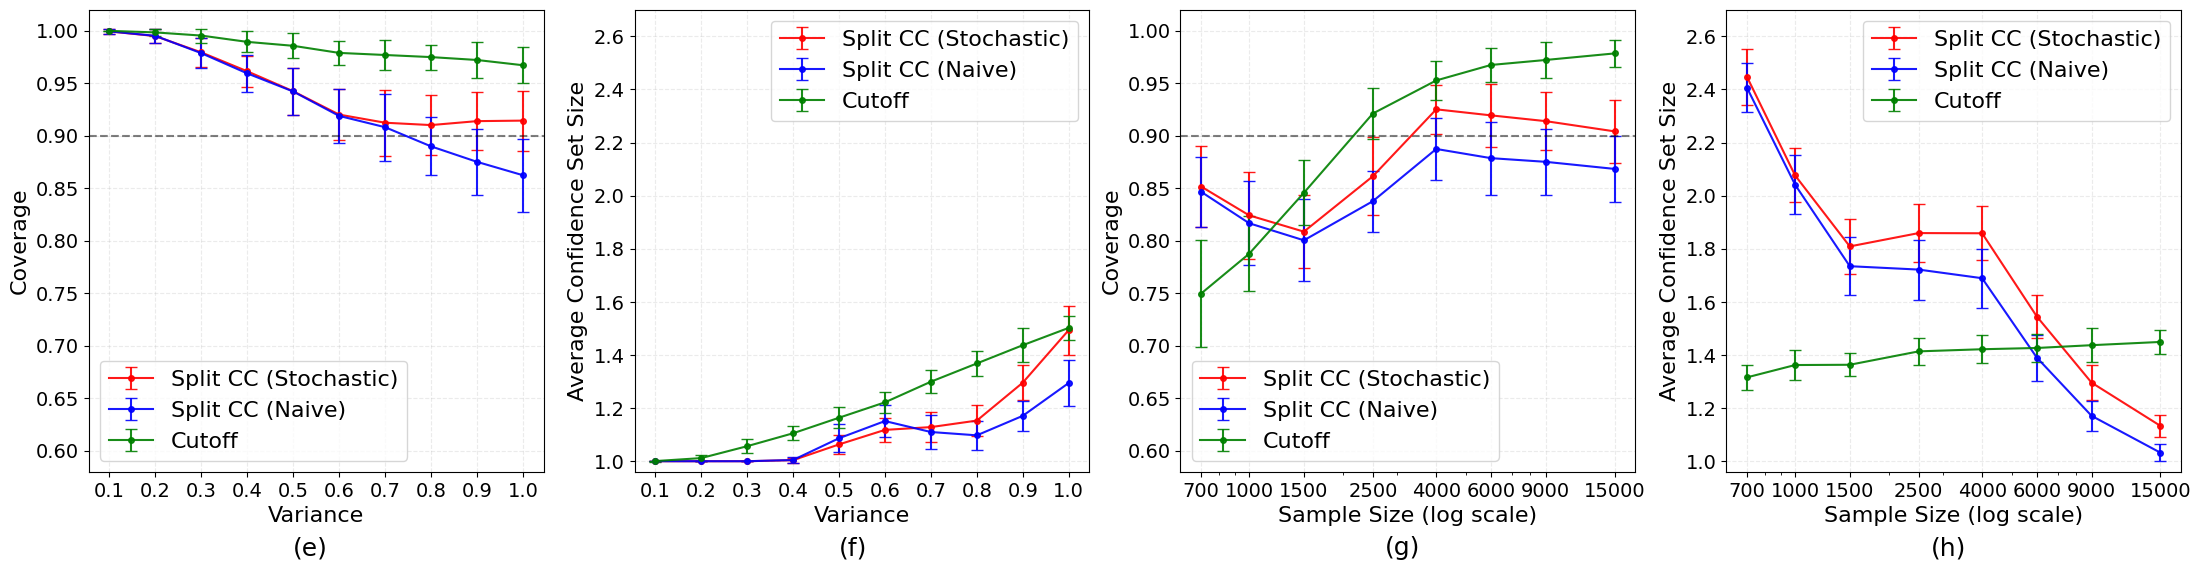

In [5]:
from matplotlib.gridspec import GridSpec

##################################
# Plots combined into one figure #
##################################
fig = plt.figure(figsize=(27, 6))
gs = GridSpec(nrows=1, ncols=4, figure=fig, wspace=0.2, hspace=0.2)

# Coverage (fixed sample size)
ax1 = fig.add_subplot(gs[0, 0])
ax1.errorbar(var_range, covs_GaMMS_mean, yerr=covs_GaMMS_std, fmt='ro-', capsize=4, markersize=4, alpha=0.9, label='Split CC (Stochastic)')
ax1.errorbar(var_range, covs_GaMM_mean, yerr=covs_GaMM_std, fmt='bo-', capsize=4, markersize=4, alpha=0.9, label='Split CC (Naive)')
ax1.errorbar(var_range, covs_GaMMC_mean, yerr=covs_GaMMC_std, fmt='go-', capsize=4, markersize=4, alpha=0.9, label='Cutoff')
ax1.axhline(y=0.9, color='k', linestyle='--', alpha=0.5)
ax1.set_xlabel('Variance', fontsize=16)
ax1.set_xticks(var_range)
ax1.set_xticklabels(labels=[f"{v:.1f}" for v in var_range], fontsize=14)
ax1.set_ylabel('Coverage', fontsize=16)
ax1.tick_params(axis='y', labelsize=14)
ax1.legend(fontsize=16)
ax1.grid(True, linestyle="--", alpha=0.25)
ax1.set_ylim((0.58, 1.02))

# Size (fixed sample size)
ax2 = fig.add_subplot(gs[0, 1])
ax2.errorbar(var_range, sizes_GaMMS_mean, yerr=sizes_GaMMS_std, fmt='ro-', capsize=4, markersize=4, alpha=0.9, label='Split CC (Stochastic)')
ax2.errorbar(var_range, sizes_GaMM_mean, yerr=sizes_GaMM_std, fmt='bo-', capsize=4, markersize=4, alpha=0.9, label='Split CC (Naive)')
ax2.errorbar(var_range, sizes_GaMMC_mean, yerr=sizes_GaMMC_std, fmt='go-', capsize=4, markersize=4, alpha=0.9, label='Cutoff')
ax2.set_xlabel('Variance', fontsize=16)
ax2.set_xticks(var_range)
ax2.set_xticklabels(labels=[f"{v:.1f}" for v in var_range], fontsize=14)
ax2.set_ylabel('Average Confidence Set Size', fontsize=16)
ax2.tick_params(axis='y', labelsize=14)
ax2.legend(fontsize=16)
ax2.grid(True, linestyle="--", alpha=0.25)
ax2.set_ylim((0.96, 2.7))

# Asymptotic coverage
ax3 = fig.add_subplot(gs[0, 2])
ax3.errorbar(n_range, asymp_covs_GaMMS_mean, yerr=asymp_covs_GaMMS_std, fmt='ro-', capsize=4, markersize=4, alpha=0.9, label='Split CC (Stochastic)')
ax3.errorbar(n_range, asymp_covs_GaMM_mean, yerr=asymp_covs_GaMM_std, fmt='bo-', capsize=4, markersize=4, alpha=0.9, label='Split CC (Naive)')
ax3.errorbar(n_range, asymp_covs_GaMMC_mean, yerr=asymp_covs_GaMMC_std, fmt='go-', capsize=4, markersize=4, alpha=0.9, label='Cutoff')
ax3.axhline(y=0.9, color='k', linestyle='--', alpha=0.5)
ax3.set_xlabel('Sample Size (log scale)', fontsize=16)
ax3.set_xscale('log')
ax3.set_xticks(n_range)
ax3.set_xticklabels([str(n) for n in n_range], fontsize=14)
ax3.set_ylabel('Coverage', fontsize=16)
ax3.tick_params(axis='y', labelsize=14)
ax3.legend(fontsize=16)
ax3.grid(True, linestyle="--", alpha=0.25)
ax3.set_ylim((0.58, 1.02))

# Asymptotic size
ax4 = fig.add_subplot(gs[0, 3])
ax4.errorbar(n_range, asymp_sizes_GaMMS_mean, yerr=asymp_sizes_GaMMS_std, fmt='ro-', capsize=4, markersize=4, alpha=0.9, label='Split CC (Stochastic)')
ax4.errorbar(n_range, asymp_sizes_GaMM_mean, yerr=asymp_sizes_GaMM_std, fmt='bo-', capsize=4, markersize=4, alpha=0.9, label='Split CC (Naive)')
ax4.errorbar(n_range, asymp_sizes_GaMMC_mean, yerr=asymp_sizes_GaMMC_std, fmt='go-', capsize=4, markersize=4, alpha=0.9, label='Cutoff')
ax4.set_xlabel('Sample Size (log scale)', fontsize=16)
ax4.set_xscale('log')
ax4.set_xticks(n_range)
ax4.set_xticklabels([str(n) for n in n_range], fontsize=14)
ax4.set_ylabel('Average Confidence Set Size', fontsize=16)
ax4.tick_params(axis='y', labelsize=14)
ax4.legend(fontsize=16)
ax4.grid(True, linestyle="--", alpha=0.25)
ax4.set_ylim((0.96, 2.7))

ax1.annotate('(e)', xy=(0.45, -0.18), xycoords='axes fraction', fontsize=18, color='black')
ax2.annotate('(f)', xy=(0.45, -0.18), xycoords='axes fraction', fontsize=18, color='black')
ax3.annotate('(g)', xy=(0.45, -0.18), xycoords='axes fraction', fontsize=18, color='black')
ax4.annotate('(h)', xy=(0.45, -0.18), xycoords='axes fraction', fontsize=18, color='black')
plt.savefig('Figures/GaMM30D5v1.pdf', bbox_inches='tight')
plt.show()